# Notebook 01 — EDA: Estación Meteorológica CESMAG

**Proyecto de Grado — Maestría en Ciencia de Datos**  
**Pontificia Universidad Javeriana Cali — Grupo 8**  
**Autores:** Laura García Salamanca, Daniel Sebastián Rosero Usamá, Juan Villalobos Mora

---

## Descripción del dataset
El archivo `Datos_2013_2026_completo.csv` contiene:
- **DateTime**: marca temporal cada 5 minutos (2013-08-01 → 2026-03-25)
- **Irradiancia**: irradiancia solar instantánea en W/m² (variable objetivo)

Las variables meteorológicas complementarias provienen de **NASA POWER** (Notebook 00)
y se integrarán en el preprocesamiento (Notebook 02).

## Contenido
1. Carga y estructura general
2. Análisis de valores faltantes
3. Estadísticas descriptivas
4. Distribución de la irradiancia
5. Patrones temporales
6. Detección de valores atípicos
7. Análisis de gaps temporales
8. Resumen de hallazgos


In [9]:
# ── 0. Importaciones ─────────────────────────────────────────────────────
!pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import subprocess
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'font.size'        : 10,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_palette('husl')
print('Librerías importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Librerías importadas: 2026-05-30 05:03:06


In [10]:
# ── 1. Google Drive — Detección automática de ruta (sin depender de tildes) ──
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Buscar el archivo por nombre exacto en todo el Drive
resultado = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'Datos_2013_2026_completo.csv'],
    capture_output=True, text=True, timeout=60
)
rutas = [r for r in resultado.stdout.strip().split('\n') if r]

if not rutas:
    raise FileNotFoundError(
        'No se encontró Datos_2013_2026_completo.csv en Drive.\n'
        'Verifica que el archivo esté subido correctamente.'
    )

RUTA_CSV   = rutas[0]
RUTA_BASE  = os.path.dirname(RUTA_CSV)
RUTA_DATOS = os.path.join(RUTA_BASE, 'datos')
RUTA_FIGS  = os.path.join(RUTA_BASE, 'figuras')
os.makedirs(RUTA_DATOS, exist_ok=True)
os.makedirs(RUTA_FIGS,  exist_ok=True)

print(f'Archivo encontrado:')
print(f'  RUTA_CSV   = "{RUTA_CSV}"')
print(f'  RUTA_BASE  = "{RUTA_BASE}"')
print(f'  RUTA_DATOS = "{RUTA_DATOS}"')
print(f'  RUTA_FIGS  = "{RUTA_FIGS}"')
print(f'  Tamaño     : {os.path.getsize(RUTA_CSV)/1024/1024:.1f} MB')

Mounted at /content/drive
Archivo encontrado:
  RUTA_CSV   = "/content/drive/MyDrive/Informer/Datos_2013_2026_completo.csv"
  RUTA_BASE  = "/content/drive/MyDrive/Informer"
  RUTA_DATOS = "/content/drive/MyDrive/Informer/datos"
  RUTA_FIGS  = "/content/drive/MyDrive/Informer/figuras"
  Tamaño     : 30.4 MB


In [11]:
# ── 1.1 Detección automática de formato y carga ───────────────────────────
print('Detectando formato del archivo...')

# Leer las primeras líneas para detectar separadores
with open(RUTA_CSV, 'r', encoding='utf-8', errors='replace') as f:
    lineas = [f.readline().strip() for _ in range(5)]

print('Muestra del archivo:')
for i, l in enumerate(lineas):
    print(f'  [{i}] {l[:120]}')

# Detectar separador de columnas
cab = lineas[0]
SEP = ';' if cab.count(';') > cab.count(',') else ','

# Detectar separador decimal
dat1 = lineas[1] if len(lineas) > 1 else ''
DEC  = ',' if (SEP == ';' and ',' in dat1) else '.'

print(f'\nSeparador columnas : "{SEP}"')
print(f'Separador decimal  : "{DEC}"')
print('\nCargando archivo... (1-2 minutos)')

df = pd.read_csv(
    RUTA_CSV,
    sep=SEP,
    decimal=DEC,
    parse_dates=['DateTime'],
    index_col='DateTime',
    encoding='utf-8'
)

# Renombrar columna para consistencia con el pipeline
df.columns    = ['RS']
df.index.name = 'timestamp'
df.sort_index(inplace=True)

# Forzar conversión a numérico — resuelve el TypeError '>' str vs int
df['RS'] = pd.to_numeric(df['RS'], errors='coerce')

print(f'\nArchivo cargado:')
print(f'  Filas    : {len(df):,}')
print(f'  Dtype RS : {df["RS"].dtype}')
print(f'  Inicio   : {df.index.min()}')
print(f'  Fin      : {df.index.max()}')
print(f'  Memoria  : {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
print()
print(df.head(5))
print('...')
print(df.tail(3))

Detectando formato del archivo...
Muestra del archivo:
  [0] DateTime,Irradiancia
  [1] 2013-08-01 00:00:00,0.0
  [2] 2013-08-01 00:05:00,0.0
  [3] 2013-08-01 00:10:00,0.0
  [4] 2013-08-01 00:15:00,0.0

Separador columnas : ","
Separador decimal  : "."

Cargando archivo... (1-2 minutos)

Archivo cargado:
  Filas    : 1,330,560
  Dtype RS : float64
  Inicio   : 2013-08-01 00:00:00
  Fin      : 2026-03-25 23:55:00
  Memoria  : 20.3 MB

                      RS
timestamp               
2013-08-01 00:00:00  0.0
2013-08-01 00:05:00  0.0
2013-08-01 00:10:00  0.0
2013-08-01 00:15:00  0.0
2013-08-01 00:20:00  0.0
...
                      RS
timestamp               
2026-03-25 23:45:00  0.0
2026-03-25 23:50:00  0.0
2026-03-25 23:55:00  0.0


In [12]:
# ── 2. Estructura y cobertura temporal ───────────────────────────────────
duracion   = df.index.max() - df.index.min()
diffs      = df.index.to_series().diff().dropna()
resolucion = diffs.mode()[0]
esperados  = int(duracion.total_seconds() / 300)  # 300 s = 5 min
cobertura  = len(df) / esperados * 100

print('=' * 60)
print('ESTRUCTURA GENERAL — DATASET CESMAG')
print('=' * 60)
print(f'  Registros totales  : {len(df):,}')
print(f'  Inicio             : {df.index.min()}')
print(f'  Fin                : {df.index.max()}')
print(f'  Duración           : {duracion.days:,} días  ({duracion.days/365.25:.2f} años)')
print(f'  Resolución (moda)  : {resolucion}')
print(f'  Registros esperados: {esperados:,}  (a 5 min exactos)')
print(f'  Cobertura          : {cobertura:.3f}%')
print(f'  Timestamps duplic. : {df.index.duplicated().sum():,}')
print()
print('Top 5 intervalos entre registros:')
print(diffs.value_counts().head().to_string())

ESTRUCTURA GENERAL — DATASET CESMAG
  Registros totales  : 1,330,560
  Inicio             : 2013-08-01 00:00:00
  Fin                : 2026-03-25 23:55:00
  Duración           : 4,619 días  (12.65 años)
  Resolución (moda)  : 0 days 00:05:00
  Registros esperados: 1,330,559  (a 5 min exactos)
  Cobertura          : 100.000%
  Timestamps duplic. : 0

Top 5 intervalos entre registros:
timestamp
0 days 00:05:00    1330559


In [13]:
# ── 3. Análisis de valores faltantes ─────────────────────────────────────
n_total   = len(df)
n_nulos   = df['RS'].isnull().sum()
n_validos = n_total - n_nulos
pct_nulos = n_nulos  / n_total * 100
pct_valid = n_validos / n_total * 100

print('VALORES FALTANTES — RS (Irradiancia Solar)')
print('=' * 50)
print(f'  Total registros  : {n_total:,}')
print(f'  Válidos          : {n_validos:,}  ({pct_valid:.3f}%)')
print(f'  Faltantes (NaN)  : {n_nulos:,}  ({pct_nulos:.3f}%)')

# Faltantes por año
falt_anio = df['RS'].isnull().groupby(df.index.year).agg(['sum', 'count'])
falt_anio.columns = ['Faltantes', 'Total']
falt_anio['Pct_%'] = (falt_anio['Faltantes'] / falt_anio['Total'] * 100).round(2)

print('\nFaltantes por año:')
print(falt_anio.to_string())

falt_anio.to_csv(os.path.join(RUTA_DATOS, 'tabla_01_faltantes_por_anio.csv'))
print('\nGuardado: tabla_01_faltantes_por_anio.csv')

VALORES FALTANTES — RS (Irradiancia Solar)
  Total registros  : 1,330,560
  Válidos          : 1,105,316  (83.071%)
  Faltantes (NaN)  : 225,244  (16.929%)

Faltantes por año:
           Faltantes   Total  Pct_%
timestamp                          
2013           10541   44064  23.92
2014           20853  105120  19.84
2015           25701  105120  24.45
2016           44633  105408  42.34
2017           43348  105120  41.24
2018           10889  105120  10.36
2019           15036  105120  14.30
2020           24650  105408  23.39
2021           14471  105120  13.77
2022           14571  105120  13.86
2023             550  105120   0.52
2024               1  105408   0.00
2025               0  105120   0.00
2026               0   24192   0.00

Guardado: tabla_01_faltantes_por_anio.csv


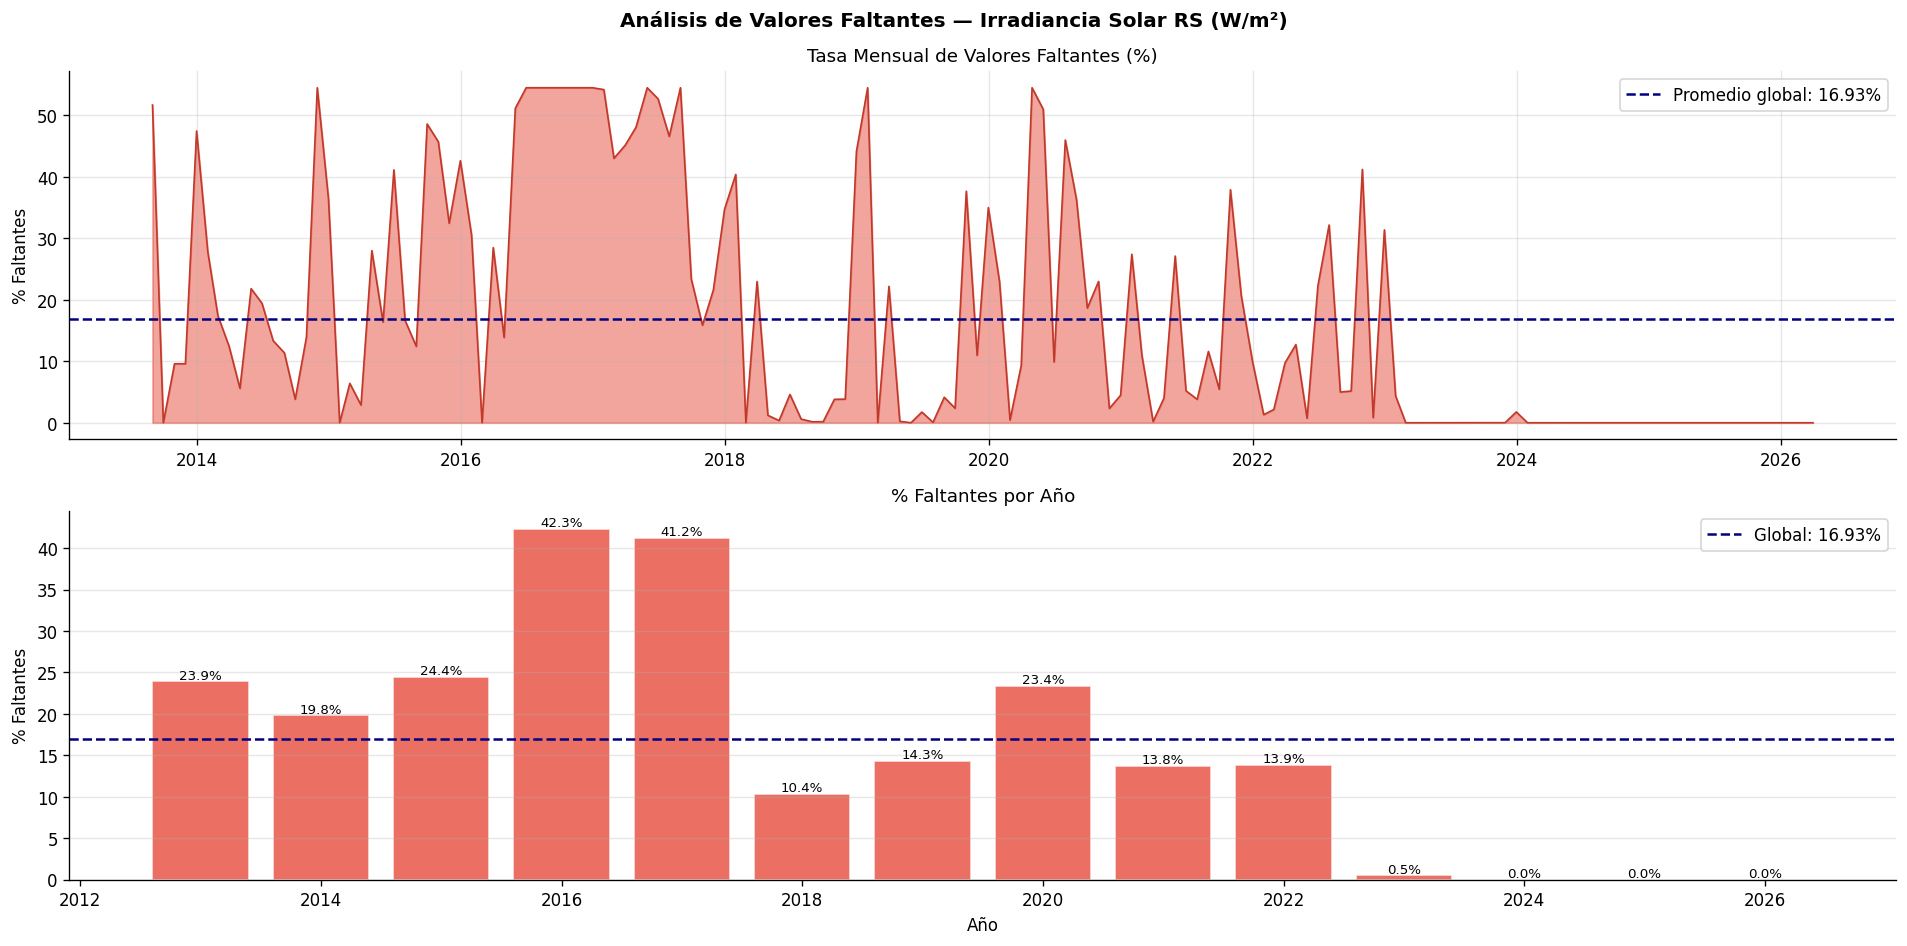

Guardado: fig_01a_faltantes.png


In [14]:
# Visualización de faltantes
falt_mes = df['RS'].isnull().resample('ME').mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Análisis de Valores Faltantes — Irradiancia Solar RS (W/m²)',
             fontsize=12, fontweight='bold')

# Panel 1: tasa mensual
axes[0].fill_between(falt_mes.index, falt_mes.values, alpha=0.5, color='#E74C3C')
axes[0].plot(falt_mes.index, falt_mes.values, color='#C0392B', lw=1)
axes[0].axhline(pct_nulos, color='navy', lw=1.5, ls='--',
                label=f'Promedio global: {pct_nulos:.2f}%')
axes[0].set_title('Tasa Mensual de Valores Faltantes (%)')
axes[0].set_ylabel('% Faltantes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: % faltantes por año
axes[1].bar(falt_anio.index, falt_anio['Pct_%'],
            color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].axhline(pct_nulos, color='navy', lw=1.5, ls='--',
                label=f'Global: {pct_nulos:.2f}%')
for yr, row in falt_anio.iterrows():
    axes[1].text(yr, row['Pct_%'] + 0.3, f"{row['Pct_%']:.1f}%",
                 ha='center', fontsize=8)
axes[1].set_title('% Faltantes por Año')
axes[1].set_ylabel('% Faltantes')
axes[1].set_xlabel('Año')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_01a_faltantes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_01a_faltantes.png')

In [15]:
# Análisis de gaps en el índice temporal
idx_esp     = pd.date_range(start=df.index.min(), end=df.index.max(), freq='5min')
ts_ausentes = idx_esp.difference(df.index)

print('GAPS TEMPORALES (timestamps ausentes en el índice)')
print('=' * 52)
print(f'  Esperados    : {len(idx_esp):,}')
print(f'  Presentes    : {len(df):,}')
print(f'  Ausentes     : {len(ts_ausentes):,}  ({len(ts_ausentes)/len(idx_esp)*100:.3f}%)')

if len(ts_ausentes) > 0:
    # Identificar bloques continuos de gaps
    s_aus   = pd.Series(ts_ausentes)
    g_diffs = s_aus.diff()
    n_bloq  = (g_diffs != pd.Timedelta('5min')).sum()
    print(f'  Bloques continuos: {n_bloq:,}')
    print(f'\n  Primeros 10 ausentes:')
    print(ts_ausentes[:10].tolist())
else:
    print('  Sin gaps en el índice temporal')

GAPS TEMPORALES (timestamps ausentes en el índice)
  Esperados    : 1,330,560
  Presentes    : 1,330,560
  Ausentes     : 0  (0.000%)
  Sin gaps en el índice temporal


In [16]:
# ── 4. Estadísticas descriptivas ─────────────────────────────────────────
rs       = df['RS'].dropna()
rs_diurn = rs[rs > 0]

print('ESTADÍSTICAS DESCRIPTIVAS — RS (Irradiancia Solar W/m²)')
print('=' * 58)
print(f'  N total           : {n_total:,}')
print(f'  N válidos         : {len(rs):,}  ({len(rs)/n_total*100:.2f}%)')
print(f'  N diurnos (RS>0)  : {len(rs_diurn):,}  ({len(rs_diurn)/len(rs)*100:.2f}% de válidos)')
print()
print(f'  Mínimo            : {rs.min():.4f} W/m²')
print(f'  Máximo            : {rs.max():.4f} W/m²')
print(f'  Media (todos)     : {rs.mean():.4f} W/m²')
print(f'  Media (diurnos)   : {rs_diurn.mean():.4f} W/m²')
print(f'  Mediana           : {rs.median():.4f} W/m²')
print(f'  Desv. estándar    : {rs.std():.4f} W/m²')
print(f'  Coef. variación   : {rs.std()/rs.mean()*100:.2f}%')
print(f'  Asimetría         : {rs.skew():.4f}')
print(f'  Curtosis          : {rs.kurtosis():.4f}')
print()
print('  Percentiles:')
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f'    P{int(q*100):>3}: {rs.quantile(q):>10.4f} W/m²')

# Guardar tabla
estadisticos = {
    'N_total'    : n_total,
    'N_validos'  : len(rs),
    'N_diurnos'  : len(rs_diurn),
    'Min'        : rs.min(),
    'Max'        : rs.max(),
    'Media_total': rs.mean(),
    'Media_diurna': rs_diurn.mean(),
    'Mediana'    : rs.median(),
    'Std'        : rs.std(),
    'CV_%'       : rs.std()/rs.mean()*100,
    'Asimetria'  : rs.skew(),
    'Curtosis'   : rs.kurtosis(),
    'P10'        : rs.quantile(0.10),
    'P25'        : rs.quantile(0.25),
    'P75'        : rs.quantile(0.75),
    'P90'        : rs.quantile(0.90),
    'P95'        : rs.quantile(0.95),
    'P99'        : rs.quantile(0.99),
}
pd.DataFrame(list(estadisticos.items()), columns=['Estadístico','Valor']
    ).to_csv(os.path.join(RUTA_DATOS, 'tabla_01_descriptivas.csv'), index=False)
print('\nGuardado: tabla_01_descriptivas.csv')

ESTADÍSTICAS DESCRIPTIVAS — RS (Irradiancia Solar W/m²)
  N total           : 1,330,560
  N válidos         : 1,105,316  (83.07%)
  N diurnos (RS>0)  : 426,136  (38.55% de válidos)

  Mínimo            : 0.0000 W/m²
  Máximo            : 1559.0000 W/m²
  Media (todos)     : 118.5294 W/m²
  Media (diurnos)   : 307.4427 W/m²
  Mediana           : 0.0000 W/m²
  Desv. estándar    : 222.5010 W/m²
  Coef. variación   : 187.72%
  Asimetría         : 2.4091
  Curtosis          : 6.0934

  Percentiles:
    P 10:     0.0000 W/m²
    P 25:     0.0000 W/m²
    P 50:     0.0000 W/m²
    P 75:   166.0000 W/m²
    P 90:   401.0000 W/m²
    P 95:   598.0000 W/m²
    P 99:  1027.0000 W/m²

Guardado: tabla_01_descriptivas.csv


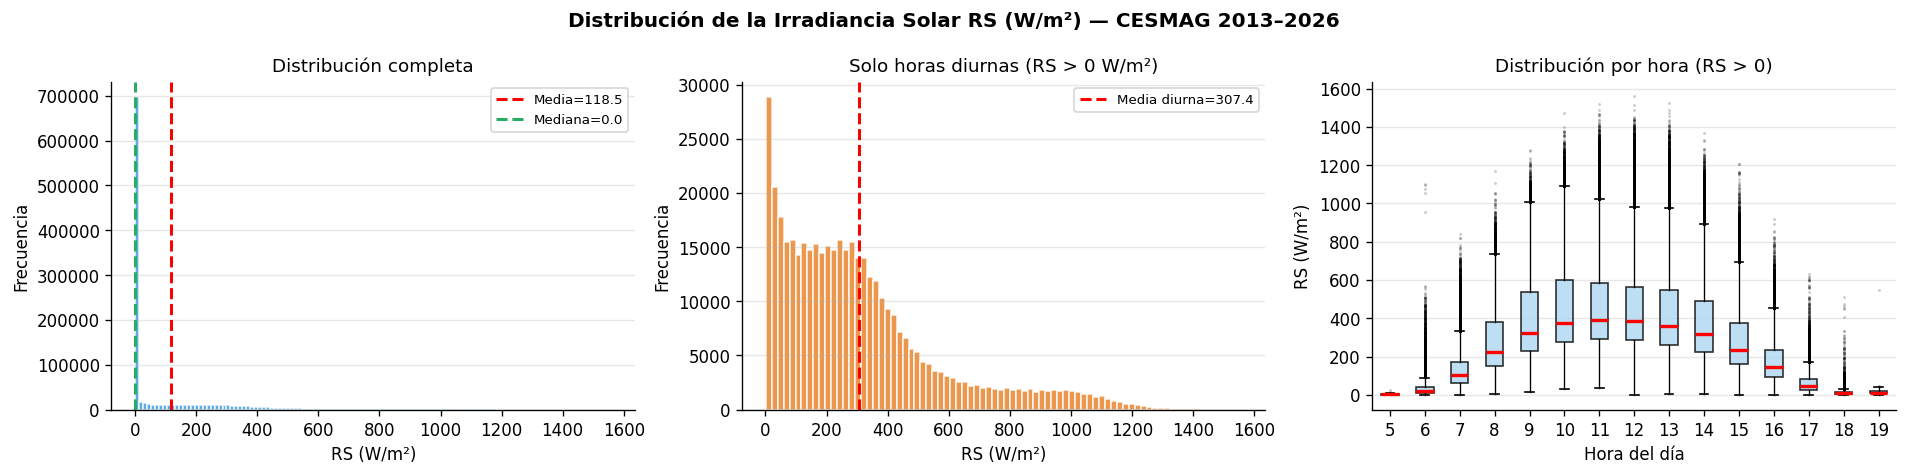

Guardado: fig_01b_distribucion.png


In [17]:
# ── 5. Distribución de la irradiancia ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de la Irradiancia Solar RS (W/m²) — CESMAG 2013–2026',
             fontsize=12, fontweight='bold')

# Histograma completo
axes[0].hist(rs, bins=120, color='#3498DB', alpha=0.8, edgecolor='white')
axes[0].axvline(rs.mean(),   color='red',     lw=1.8, ls='--', label=f'Media={rs.mean():.1f}')
axes[0].axvline(rs.median(), color='#27AE60', lw=1.8, ls='--', label=f'Mediana={rs.median():.1f}')
axes[0].set_title('Distribución completa')
axes[0].set_xlabel('RS (W/m²)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Solo valores diurnos
axes[1].hist(rs_diurn, bins=80, color='#E67E22', alpha=0.8, edgecolor='white')
axes[1].axvline(rs_diurn.mean(), color='red', lw=1.8, ls='--',
                label=f'Media diurna={rs_diurn.mean():.1f}')
axes[1].set_title('Solo horas diurnas (RS > 0 W/m²)')
axes[1].set_xlabel('RS (W/m²)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

# Boxplot por hora del día
df_box    = pd.DataFrame({'hora': df.index.hour, 'RS': df['RS'].values})
df_box    = df_box[df_box['RS'] > 0]
datos_box = [df_box[df_box['hora'] == h]['RS'].dropna().values for h in range(5, 20)]
axes[2].boxplot(datos_box, labels=range(5, 20), patch_artist=True,
                boxprops=dict(facecolor='#AED6F1', alpha=0.8),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', ms=1.5, alpha=0.2),
                whiskerprops=dict(lw=0.8))
axes[2].set_title('Distribución por hora (RS > 0)')
axes[2].set_xlabel('Hora del día')
axes[2].set_ylabel('RS (W/m²)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_01b_distribucion.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_01b_distribucion.png')

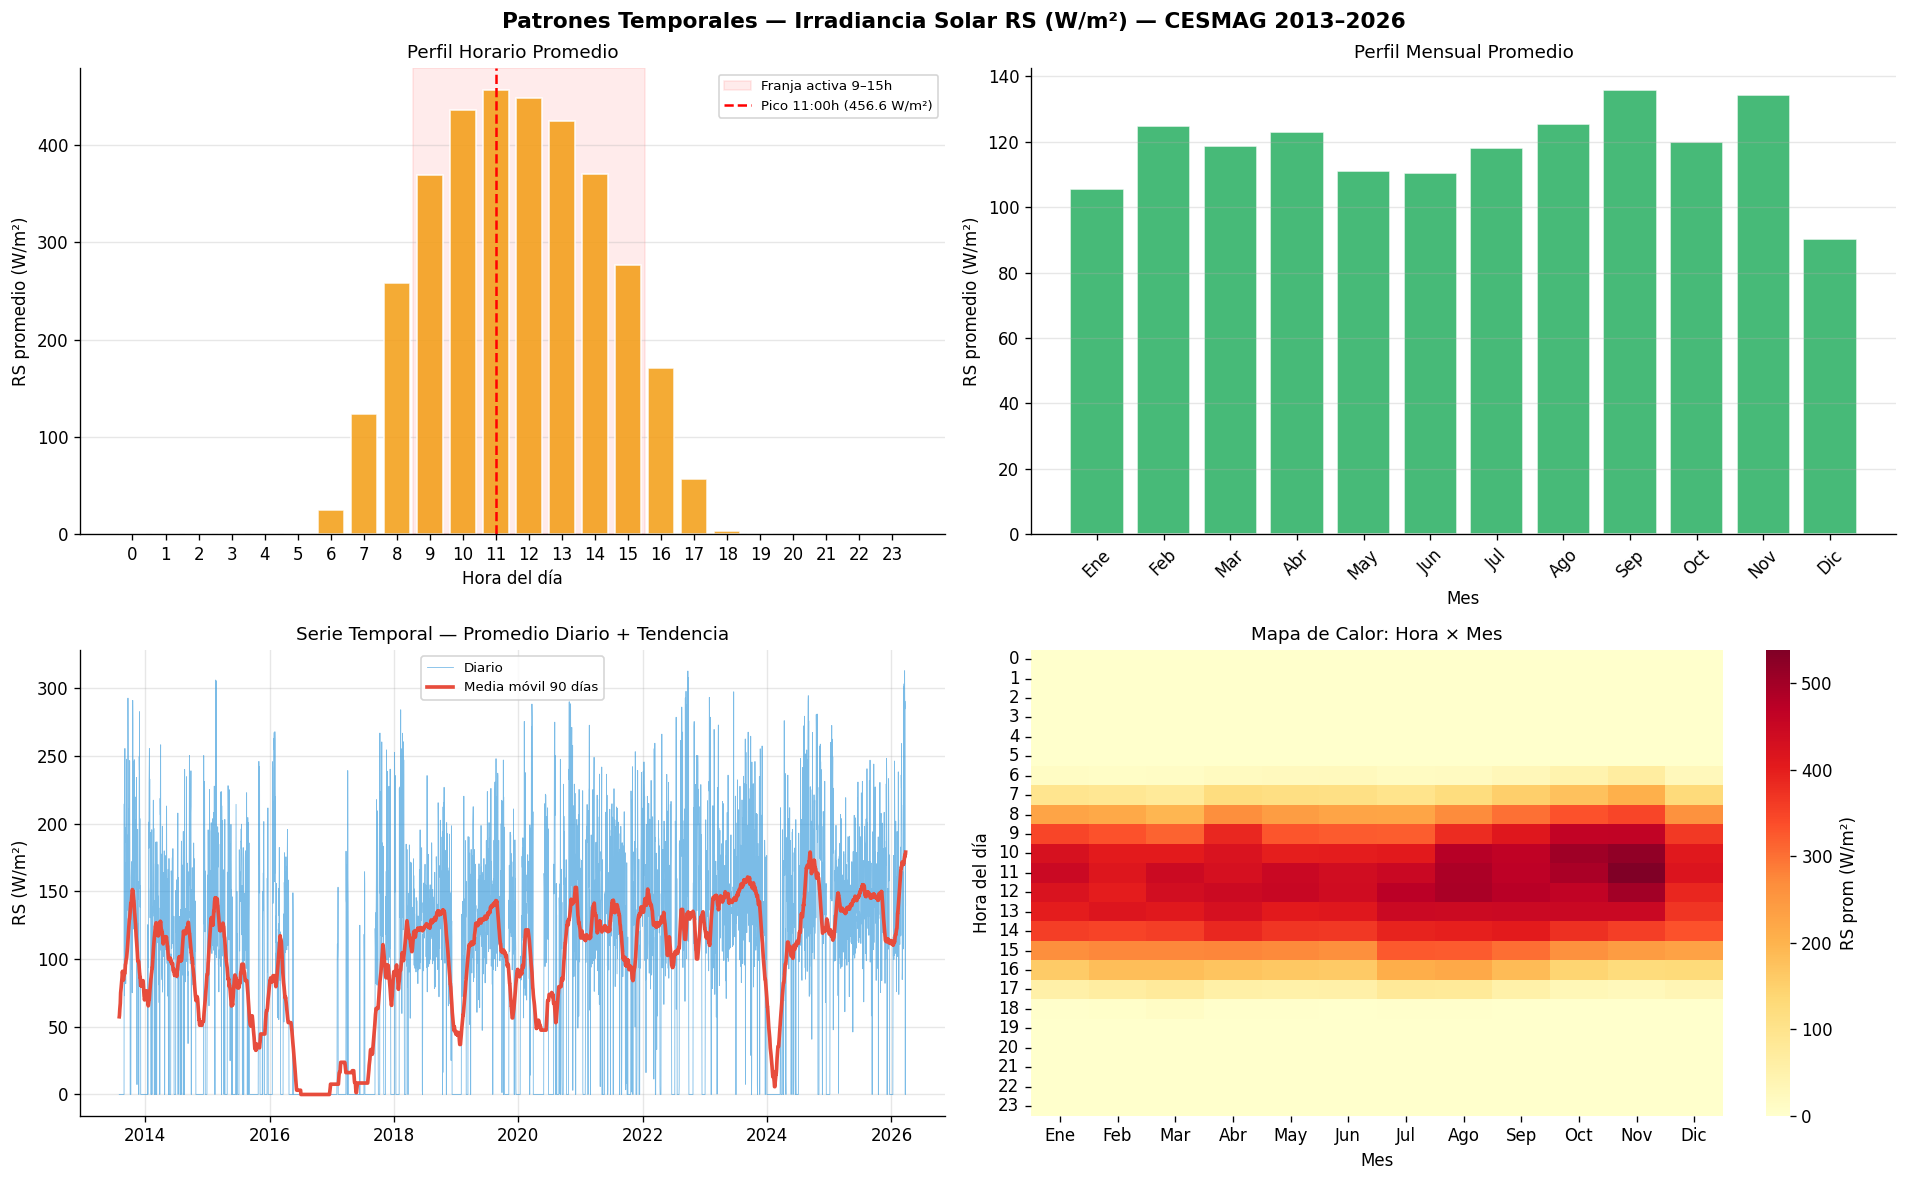

Guardado: fig_01c_patrones_temporales.png


In [18]:
# ── 6. Patrones temporales ────────────────────────────────────────────────
mes_etiq = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Patrones Temporales — Irradiancia Solar RS (W/m²) — CESMAG 2013–2026',
             fontsize=13, fontweight='bold')

# Perfil horario promedio
ph = df['RS'].groupby(df.index.hour).mean()
axes[0,0].bar(ph.index, ph.values, color='#F39C12', alpha=0.85, edgecolor='white', zorder=2)
axes[0,0].axvspan(8.5, 15.5, alpha=0.08, color='red', zorder=1, label='Franja activa 9–15h')
axes[0,0].axvline(ph.idxmax(), color='red', lw=1.5, ls='--',
                   label=f'Pico {ph.idxmax()}:00h ({ph.max():.1f} W/m²)')
axes[0,0].set_title('Perfil Horario Promedio')
axes[0,0].set_xlabel('Hora del día')
axes[0,0].set_ylabel('RS promedio (W/m²)')
axes[0,0].set_xticks(range(0, 24))
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Perfil mensual promedio
pm = df['RS'].groupby(df.index.month).mean()
axes[0,1].bar(pm.index, pm.values, color='#27AE60', alpha=0.85, edgecolor='white')
axes[0,1].set_title('Perfil Mensual Promedio')
axes[0,1].set_xlabel('Mes')
axes[0,1].set_ylabel('RS promedio (W/m²)')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(mes_etiq, rotation=45)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Serie diaria + media móvil 90 días
rs_d  = df['RS'].resample('D').mean()
rs_ma = rs_d.rolling(90, center=True, min_periods=30).mean()
axes[1,0].plot(rs_d.index, rs_d.values, color='#3498DB', lw=0.5, alpha=0.65, label='Diario')
axes[1,0].plot(rs_ma.index, rs_ma.values, color='#E74C3C', lw=2.2, label='Media móvil 90 días')
axes[1,0].set_title('Serie Temporal — Promedio Diario + Tendencia')
axes[1,0].set_ylabel('RS (W/m²)')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Mapa de calor hora × mes
df_hm = pd.DataFrame({'h': df.index.hour, 'm': df.index.month, 'RS': df['RS'].values})
pivot = df_hm.groupby(['h','m'])['RS'].mean().unstack()
sns.heatmap(pivot, ax=axes[1,1], cmap='YlOrRd',
            xticklabels=mes_etiq, cbar_kws={'label': 'RS prom (W/m²)'})
axes[1,1].set_title('Mapa de Calor: Hora × Mes')
axes[1,1].set_xlabel('Mes')
axes[1,1].set_ylabel('Hora del día')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_01c_patrones_temporales.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_01c_patrones_temporales.png')

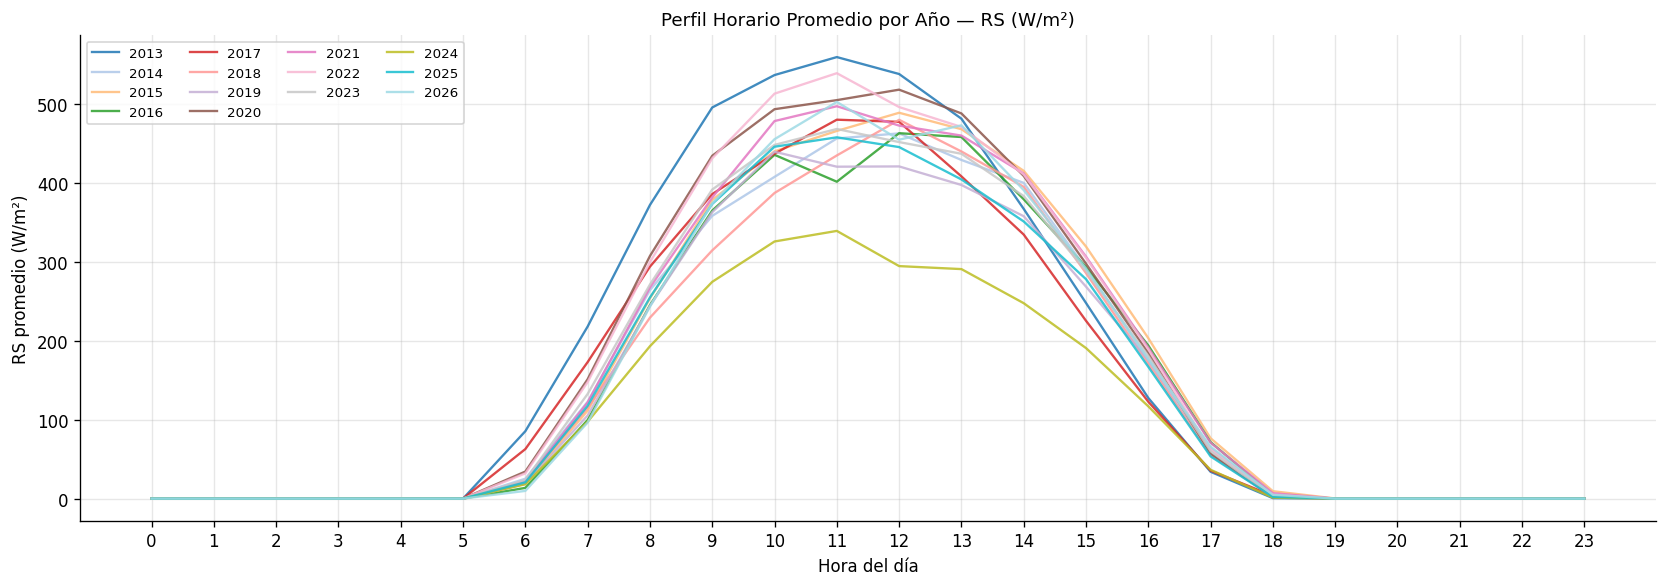

Guardado: fig_01d_perfil_por_anio.png


In [19]:
# Perfil horario por año — detecta cambios de comportamiento o fallas del sensor
anios = sorted(df.index.year.unique())
cmap  = plt.cm.get_cmap('tab20', len(anios))

fig, ax = plt.subplots(figsize=(14, 5))
for i, a in enumerate(anios):
    s = df['RS'][df.index.year == a]
    p = s.groupby(s.index.hour).mean()
    ax.plot(p.index, p.values, lw=1.4, color=cmap(i), alpha=0.85, label=str(a))

ax.set_title('Perfil Horario Promedio por Año — RS (W/m²)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('RS promedio (W/m²)')
ax.set_xticks(range(0, 24))
ax.legend(ncol=4, fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_01d_perfil_por_anio.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_01d_perfil_por_anio.png')

In [20]:
# ── 7. Detección de valores atípicos ─────────────────────────────────────

# Método IQR
q1  = rs.quantile(0.25)
q3  = rs.quantile(0.75)
iqr = q3 - q1
li  = q1 - 1.5 * iqr
ls  = q3 + 1.5 * iqr

n_inf = (rs < li).sum()
n_sup = (rs > ls).sum()

print('DETECCIÓN DE OUTLIERS')
print('=' * 55)
print('Método IQR × 1.5:')
print(f'  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}')
print(f'  Límite inferior : {li:.2f} W/m²')
print(f'  Límite superior : {ls:.2f} W/m²')
print(f'  Outliers inf    : {n_inf:,}  ({n_inf/len(rs)*100:.3f}%)')
print(f'  Outliers sup    : {n_sup:,}  ({n_sup/len(rs)*100:.3f}%)')
print()
print('Límites físicos:')
print(f'  RS < 0   (imposible)    : {(df["RS"] < 0).sum():,}')
print(f'  RS > 1400 (sospechoso)  : {(df["RS"] > 1400).sum():,}')
print(f'  RS > 1559 (máx docum.)  : {(df["RS"] > 1559).sum():,}')
print()
print('Top 15 valores máximos:')
print(df['RS'].nlargest(15).to_string())

# Guardar tabla
pd.DataFrame({
    'Metodo': ['IQR x1.5','Fisico'],
    'Lim_inf': [round(li,2), 0],
    'Lim_sup': [round(ls,2), 1559],
    'N_out_inf': [n_inf, (df['RS']<0).sum()],
    'N_out_sup': [n_sup, (df['RS']>1559).sum()]
}).to_csv(os.path.join(RUTA_DATOS, 'tabla_01_outliers.csv'), index=False)
print('\nGuardado: tabla_01_outliers.csv')

DETECCIÓN DE OUTLIERS
Método IQR × 1.5:
  Q1=0.00  Q3=166.00  IQR=166.00
  Límite inferior : -249.00 W/m²
  Límite superior : 415.00 W/m²
  Outliers inf    : 0  (0.000%)
  Outliers sup    : 103,679  (9.380%)

Límites físicos:
  RS < 0   (imposible)    : 0
  RS > 1400 (sospechoso)  : 55
  RS > 1559 (máx docum.)  : 0

Top 15 valores máximos:
timestamp
2023-03-18 12:15:00    1559.0
2015-03-02 13:20:00    1524.0
2017-09-18 11:40:00    1522.0
2013-09-10 12:55:00    1512.0
2020-09-04 11:25:00    1488.0
2015-03-17 13:40:00    1487.0
2020-10-02 12:20:00    1487.0
2020-10-08 10:40:00    1473.0
2015-03-02 13:15:00    1471.0
2013-09-13 11:30:00    1468.0
2013-10-10 11:10:00    1466.0
2013-10-10 11:05:00    1461.0
2015-02-25 11:55:00    1457.0
2023-04-06 13:30:00    1456.0
2023-03-18 12:30:00    1450.0

Guardado: tabla_01_outliers.csv


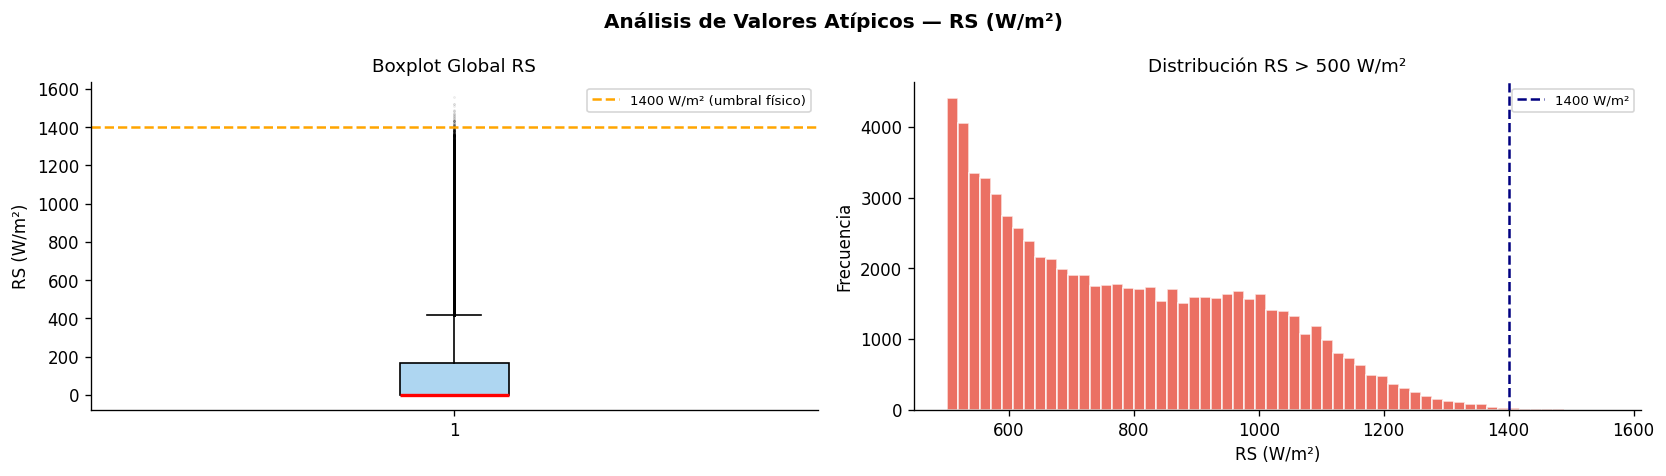

Guardado: fig_01e_outliers.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Análisis de Valores Atípicos — RS (W/m²)', fontsize=12, fontweight='bold')

# Boxplot global
axes[0].boxplot(rs, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#AED6F1'),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', ms=1, alpha=0.1))
axes[0].axhline(1400, color='orange', lw=1.5, ls='--', label='1400 W/m² (umbral físico)')
axes[0].set_title('Boxplot Global RS')
axes[0].set_ylabel('RS (W/m²)')
axes[0].legend(fontsize=8)

# Histograma zona alta
rs_alta = rs[rs > 500]
axes[1].hist(rs_alta, bins=60, color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].axvline(1400, color='navy', lw=1.5, ls='--', label='1400 W/m²')
axes[1].set_title('Distribución RS > 500 W/m²')
axes[1].set_xlabel('RS (W/m²)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_01e_outliers.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_01e_outliers.png')

In [22]:
# ── 8. Resumen de hallazgos ───────────────────────────────────────────────
hora_pico = ph.idxmax()
mes_max   = pm.idxmax()

print('=' * 65)
print('RESUMEN DE HALLAZGOS — BASE PARA PREPROCESAMIENTO (Notebook 02)')
print('=' * 65)
print(f"""
DATASET
  Fuente     : Estación Davis Vantage Pro — Universidad CESMAG, Pasto
  Período    : {df.index.min().date()} → {df.index.max().date()}
  Registros  : {len(df):,}  |  Resolución: 5 minutos
  Variables  : DateTime + Irradiancia (RS)

CALIDAD DE DATOS
  Faltantes  : {n_nulos:,}  ({pct_nulos:.3f}%)
  Cobertura  : {cobertura:.3f}%
  RS < 0     : {int((df['RS']<0).sum()):,}  → corregir a 0
  RS > 1400  : {int((df['RS']>1400).sum()):,}  → revisar

ESTADÍSTICAS CLAVE
  Rango      : {rs.min():.2f} – {rs.max():.2f} W/m²
  Media      : {rs.mean():.2f} W/m²  |  Std: {rs.std():.2f} W/m²
  Asimetría  : {rs.skew():.3f}  (distribución sesgada a la derecha)
  Pico diurno: ~{hora_pico}:00h  |  Mes mayor irrad.: {mes_etiq[mes_max-1]}

ACCIONES DE PREPROCESAMIENTO (Notebook 02)
  1. Construir índice completo a 5 min (rellenar gaps temporales)
  2. Corregir RS < 0 → asignar 0
  3. Imputar faltantes por promedio histórico hora × mes
  4. Integrar NASA POWER (horario → interpolar a 5 min)
  5. Crear variables temporales cíclicas (sin/cos hora, mes, día_año)
  6. Calcular índice de claridad KT = ALLSKY / CLRSKY
  7. Normalizar con MinMaxScaler
  8. Particionar train/val/test respetando orden temporal
""")

print('Archivos generados en /datos/:')
for f in sorted(os.listdir(RUTA_DATOS)):
    tam = os.path.getsize(os.path.join(RUTA_DATOS, f)) / 1024
    print(f'  {f:<45} ({tam:>7.1f} KB)')

print('\nFiguras generadas en /figuras/:')
for f in sorted(os.listdir(RUTA_FIGS)):
    tam = os.path.getsize(os.path.join(RUTA_FIGS, f)) / 1024
    print(f'  {f:<45} ({tam:>7.1f} KB)')

print('\n✓ Notebook 01 completado.')
print('  Siguiente: 02_preprocesamiento.ipynb')

RESUMEN DE HALLAZGOS — BASE PARA PREPROCESAMIENTO (Notebook 02)

DATASET
  Fuente     : Estación Davis Vantage Pro — Universidad CESMAG, Pasto
  Período    : 2013-08-01 → 2026-03-25
  Registros  : 1,330,560  |  Resolución: 5 minutos
  Variables  : DateTime + Irradiancia (RS)

CALIDAD DE DATOS
  Faltantes  : 225,244  (16.929%)
  Cobertura  : 100.000%
  RS < 0     : 0  → corregir a 0
  RS > 1400  : 55  → revisar

ESTADÍSTICAS CLAVE
  Rango      : 0.00 – 1559.00 W/m²
  Media      : 118.53 W/m²  |  Std: 222.50 W/m²
  Asimetría  : 2.409  (distribución sesgada a la derecha)
  Pico diurno: ~11:00h  |  Mes mayor irrad.: Sep

ACCIONES DE PREPROCESAMIENTO (Notebook 02)
  1. Construir índice completo a 5 min (rellenar gaps temporales)
  2. Corregir RS < 0 → asignar 0
  3. Imputar faltantes por promedio histórico hora × mes
  4. Integrar NASA POWER (horario → interpolar a 5 min)
  5. Crear variables temporales cíclicas (sin/cos hora, mes, día_año)
  6. Calcular índice de claridad KT = ALLSKY / CLR